[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ee-ortiz/ISIS-4825_202510_IMAGENES_Y_VISION/blob/main/Laboratorio_08/MISIS4825_Laboratorio08_Taller.ipynb)

![image](https://drive.google.com/u/0/uc?id=15DUc09hFGqR8qcpYiN1OajRNaASmiL6d&export=download)

# Laboratorio 09 – Taller: Redes Neuronales Convolucionales con Modelos Fundacionales

## Autores: Harvey Benitez y Estefanía Laverde

## Introducción

En este taller abordaremos el tema de las redes neuronales convolucionales (CNN) y la aplicación de **modelos fundacionales** mediante *transfer learning*. Para ello, utilizaremos el conjunto de datos **drone-bird classification** de Kaggle.

El objetivo es comparar el rendimiento de un modelo CNN entrenado desde cero con el de un modelo fundacional (por ejemplo, VGG16) adaptado a nuestra tarea de **clasificación de Drones y aves**.

## Objetivos

1. **Entrenar un modelo CNN desde cero** utilizando Keras y TensorFlow.
2. **Aplicar transfer learning** con un modelo fundacional, aprovechando características previamente aprendidas en conjuntos de datos masivos.
3. **Comparar** el rendimiento y la eficiencia de ambos enfoques.
4. **Experimentar** con distintos modelos fundacionales y diferentes configuraciones de hiperparámetros.


**Datos:** [drone-bird classification](https://www.kaggle.com/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images)

## 1. Descarga y Preparación del Dataset de Kaggle

In [1]:
import os
import json

In [2]:
# Instalación de Kaggle
!pip install kaggle --quiet

In [9]:

os.environ['KAGGLE_USERNAME'] = "estefanialaverde"
os.environ['KAGGLE_KEY'] = "KGAT_ea3bf2a58d6dea7548c150f60792af6a"

# Descarga del dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('imbikramsaha/drone-bird-classification', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/imbikramsaha/drone-bird-classification


In [ ]:
# Cargar credenciales desde kaggle.json
with open('kaggle.json', 'r') as f:
    kaggle_creds = json.load(f)
os.environ['KAGGLE_USERNAME'] = kaggle_creds['username']
os.environ['KAGGLE_KEY'] = kaggle_creds['key']

# Descarga del dataset
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()
api.dataset_download_files('imbikramsaha/drone-bird-classification', path='data', unzip=True)

## 2. Exploración de Datos

Vamos a inspeccionar la carpeta que contiene las imágenes de drones y aves y crear un DataFrame con la ruta de cada imagen y su etiqueta. Luego, mostraremos cada una de las categorías y un breve conteo de cuántas imágenes hay por categoría.

Total de imágenes: 324

Número de imágenes por categoría:
label
birds     164
drones    160
Name: count, dtype: int64


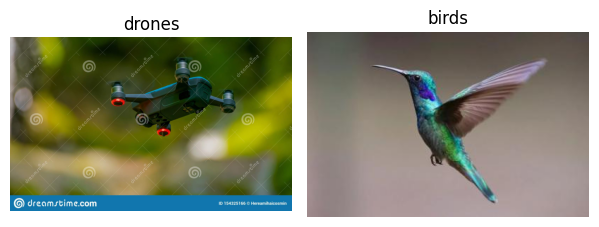

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Directorio base que contiene las carpetas 'train' y 'test'
base_dir = 'data/drone_or_bird'

filepaths = []
labels = []

# Recorrer las carpetas 'train' y 'test'
for label in os.listdir(base_dir):
    label_path = os.path.join(base_dir, label)
    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            ext = os.path.splitext(file)[1].lower()
            if ext in ['.png', '.jpg', '.jpeg']:
                filepaths.append(os.path.join(label_path, file))
                labels.append(label)

# Crear DataFrame con las rutas y etiquetas
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

# Mostrar conteo total y por categoría
print("Total de imágenes:", len(data_df))
print("\nNúmero de imágenes por categoría:")
print(data_df['label'].value_counts())

# Mostrar una imagen por categoría
categorias = data_df['label'].unique()
num_muestras = len(categorias)

plt.figure(figsize=(15, 10))
for i, categoria in enumerate(categorias[:num_muestras]):
    img_path = data_df[data_df['label'] == categoria].iloc[0]['filepath']
    img = mpimg.imread(img_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{categoria}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos

Dividimos el dataset completo en tres conjuntos:
- **Entrenamiento (70%)**
- **Validación (20%)**
- **Prueba (10%)**

Esta separación nos permitirá evaluar la capacidad de generalización de nuestros modelos.

In [11]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en 70% entrenamiento y 30% (validación + prueba)
train_df, test_val_df = train_test_split(
    data_df, test_size=0.3, random_state=42, stratify=data_df['label']
)

# A partir del 30% restante, dividir en 2/3 para validación y 1/3 para prueba (~20% y ~10% del total, respectivamente)
val_df, test_df = train_test_split(
    test_val_df, test_size=(1/3), random_state=42, stratify=test_val_df['label']
)

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Prueba:", len(test_df))


Entrenamiento: 226
Validación: 65
Prueba: 33


## 4. Generadores de Imágenes

Utilizaremos la clase `ImageDataGenerator` de Keras para:
- Reescalar los valores de píxel al rango [0, 1].
- Aplicar data augmentation (rotación, volteo horizontal) en el conjunto de entrenamiento.
- Mantener intactos los conjuntos de validación y prueba (solo reescalado).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(
    rescale=1./255
)

img_size = (128, 128)  # Compatible con la mayoría de modelos fundacionales
batch_size = 32

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=img_size, batch_size=batch_size,
    class_mode='categorical', shuffle=False
)

# Diccionario con nombre de clase -> índice
labels_map = train_gen.class_indices

# Invertimos el diccionario para tener índice -> nombre de clase
idx_to_class = {v: k for k, v in labels_map.items()}

print("\nCategorías reconocidas:")
for idx in sorted(idx_to_class):
    print(f"  Clase {idx}: '{idx_to_class[idx]}'")

num_classes = len(labels_map)
print("Número de clases:", num_classes)

Found 226 validated image filenames belonging to 2 classes.
Found 65 validated image filenames belonging to 2 classes.
Found 33 validated image filenames belonging to 2 classes.

Categorías reconocidas:
  Clase 0: 'birds'
  Clase 1: 'drones'
Número de clases: 2


## 5. Construcción del Modelo de Red Convolucional

En esta sección, definiremos una CNN desde cero (modelo *scratch*) para la clasificación de fracturas. Este modelo tendrá varias capas convolucionales y capas de pooling, seguido de capas densas para la clasificación.


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_scratch = Sequential([
    # Primer bloque convolucional
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Segundo bloque
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Tercer bloque
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Aplanamiento y capas densas
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_scratch.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,538,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,677,986 (21.66 MB)

 Trainable params: 5,677,986 (21.66 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Definición de Callbacks

Utilizamos *ModelCheckpoint* para guardar la mejor versión del modelo, *EarlyStopping* para detener el entrenamiento cuando la métrica de validación deje de mejorar y *ReduceLROnPlateau* para ajustar dinámicamente la tasa de aprendizaje.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_scratch.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_scratch = [
    ModelCheckpoint('best_model_scratch.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

## 7. Entrenamiento del Modelo

Entrenamos la red desde cero con los parámetros definidos anteriormente.  

In [ ]:
import tensorflow as tf

epochs_scratch = 15
with tf.device('/device:GPU:0'):
    history_scratch = model_scratch.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_scratch,
        callbacks=callbacks_scratch
    )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4273 - loss: 0.8814 - val_accuracy: 0.5077 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 499ms/step - accuracy: 0.5336 - loss: 0.6966 - val_accuracy: 0.5077 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 547ms/step - accuracy: 0.5036 - loss: 0.6912 - val_accuracy: 0.5231 - val_loss: 0.6923 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 607ms/step - accuracy: 0.5876 - loss: 0.6914 - val_accuracy: 0.5077 - val_loss: 0.6926 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 454ms/step - accuracy: 0.5336 - loss: 0.6911 - val_accuracy: 0.5231 - val_loss: 0.6925 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 489ms/step - accuracy: 0.5018 - loss: 0.6907 - val_accuracy: 0.5231 - val_loss: 0.6902 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 626ms/step - accuracy: 0.5633 - loss: 0.6855 - val_accuracy: 0.

## 8. Evaluación del Modelo

Visualizaremos las curvas de entrenamiento (precisión y pérdida) y cargaremos la mejor versión del modelo para evaluar en el conjunto de prueba.

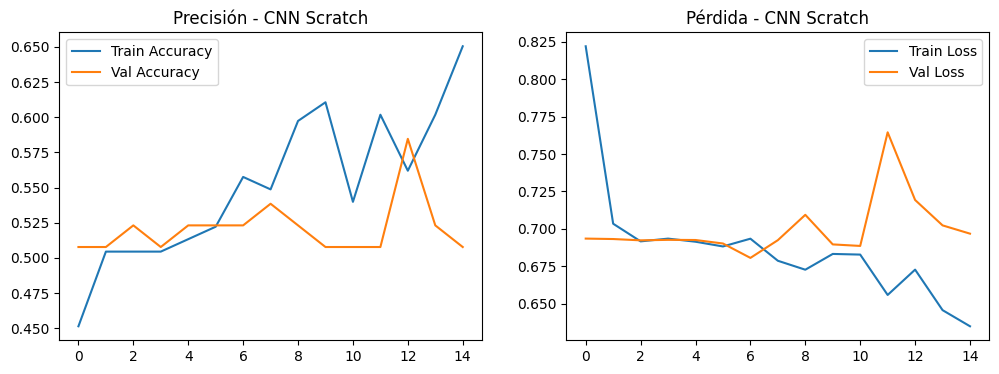

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step


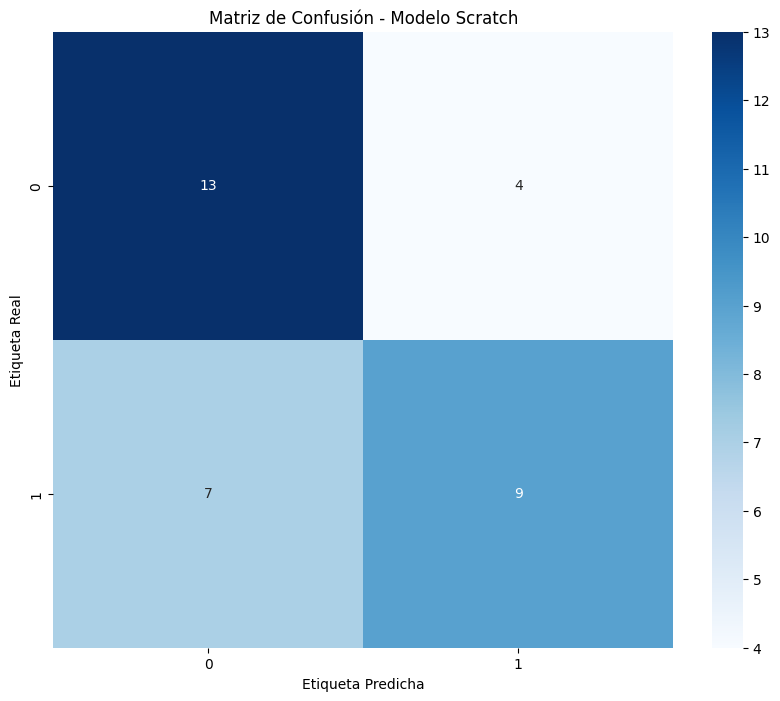

Reporte de Clasificación - Modelo Scratch

              precision    recall  f1-score   support

       birds       0.65      0.76      0.70        17
      drones       0.69      0.56      0.62        16

    accuracy                           0.67        33
   macro avg       0.67      0.66      0.66        33
weighted avg       0.67      0.67      0.66        33



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc = history_scratch.history['accuracy']
val_acc = history_scratch.history['val_accuracy']
loss = history_scratch.history['loss']
val_loss = history_scratch.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title('Precisión - CNN Scratch')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Pérdida - CNN Scratch')
plt.show()

# Cargar el mejor modelo y evaluar
best_scratch_model = load_model('best_model_scratch.keras')
test_gen.reset()
preds_scratch = best_scratch_model.predict(test_gen, verbose=1)
y_pred_scratch = np.argmax(preds_scratch, axis=1)
y_true = test_gen.classes

cm_scratch = confusion_matrix(y_true, y_pred_scratch)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Modelo Scratch')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Modelo Scratch")
print()
print(classification_report(y_true, y_pred_scratch, target_names=labels_map, zero_division=0))

## 9. Transfer Learning con Modelos Fundacionales

En esta sección se aprovechará el poder de un modelo pre-entrenado, en concreto **VGG16**, para aplicar *transfer learning* en nuestra tarea de clasificación de imágenes. Utilizar un modelo como VGG16 permite:
  
- **Reducción en el tiempo de entrenamiento:** El modelo base ya ha sido entrenado en un conjunto masivo (ImageNet), lo que significa que las capas iniciales han aprendido a extraer características generales muy útiles.
- **Mejor rendimiento en datasets limitados:** Al reutilizar las representaciones aprendidas, se pueden obtener resultados competitivos incluso cuando el conjunto de datos de destino es relativamente pequeño.
  
### Sobre VGG16

VGG16 fue desarrollado por Simonyan y Zisserman en su artículo *"Very Deep Convolutional Networks for Large-Scale Image Recognition"* ([ver paper](https://arxiv.org/abs/1409.1556)). Algunas de sus características destacadas son:

- **Filtros uniformes:** Emplea filtros uniformes de 3x3 a lo largo de toda la arquitectura, lo que facilita la extracción sistemática de patrones jerárquicos a distintos niveles de abstracción.
- **Estructura profunda:** Consta de 16 capas con pesos (13 capas convolucionales y 3 capas densas), lo que permite una representación rica y detallada de las imágenes.
- **Simplicidad en el diseño:** A pesar de su profundidad, utiliza únicamente capas convolucionales con pequeños filtros y capas de pooling, lo que resulta en una arquitectura elegante y uniforme.

A continuación, se muestra un diagrama ilustrativo de la arquitectura VGG16:

![Arquitectura VGG16](https://miro.medium.com/v2/resize:fit:720/1*lXCy8RLUOtAwoS2H4ortZA.png)


### Implementación con VGG16

El siguiente bloque de código carga VGG16 sin la parte superior (la capa de clasificación final), congela sus capas para evitar su reentrenamiento, y añade una parte superior que se adapta a nuestro problema. Se entrena el modelo y se guardan las mejores versiones según la métrica de validación.

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Cargar VGG16 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base para no reentrenarlas
for layer in base_model_vgg.layers:
    layer.trainable = False

# Construir el modelo de transfer learning
model_vgg = Sequential([
    base_model_vgg,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Mostrar la arquitectura del modelo
model_vgg.summary()

# Compilar el modelo
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks para guardar el mejor modelo, detener tempranamente y reducir la tasa de aprendizaje
callbacks_vgg = [
    ModelCheckpoint('best_model_vgg.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# Entrenar el modelo de transfer learning
epochs_vgg = 15
with tf.device('/device:GPU:0'):
    history_vgg = model_vgg.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_vgg,
        callbacks=callbacks_vgg
    )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,610 (56.38 MB)

 Trainable params: 65,922 (257.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.5265 - loss: 0.7297 - val_accuracy: 0.6000 - val_loss: 0.6307 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 535ms/step - accuracy: 0.6770 - loss: 0.6171 - val_accuracy: 0.7385 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - accuracy: 0.7035 - loss: 0.5637 - val_accuracy: 0.8769 - val_loss: 0.4632 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.7965 - loss: 0.4914 - val_accuracy: 0.8308 - val_loss: 0.4395 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 621ms/step - accuracy: 0.7965 - loss: 0.4698 - val_accuracy: 0.8923 - val_loss: 0.3833 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 495ms/step - accuracy: 0.8363 - loss: 0.4151 - val_accuracy: 0.9077 - val_loss: 0.3568 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 508ms/step - accuracy: 0.8097 - loss: 0.4004 - val_accuracy: 0.

### Evaluación del Modelo

Visualizaremos las curvas de entrenamiento y evaluaremos la mejor versión del modelo en el conjunto de prueba.

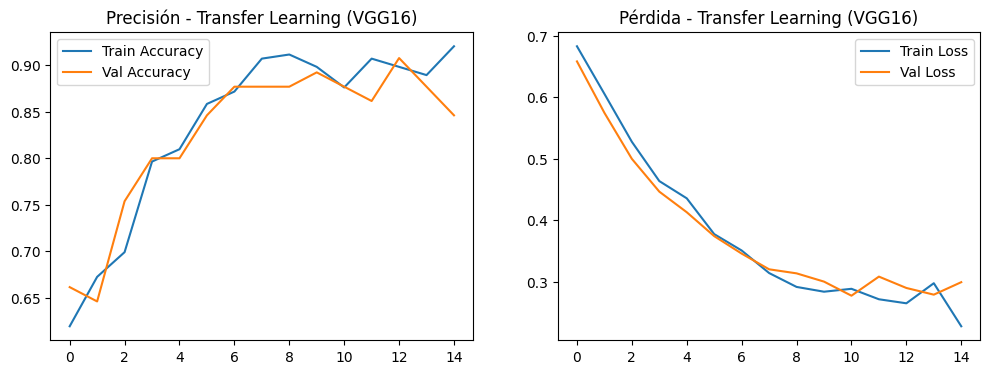

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 761ms/step


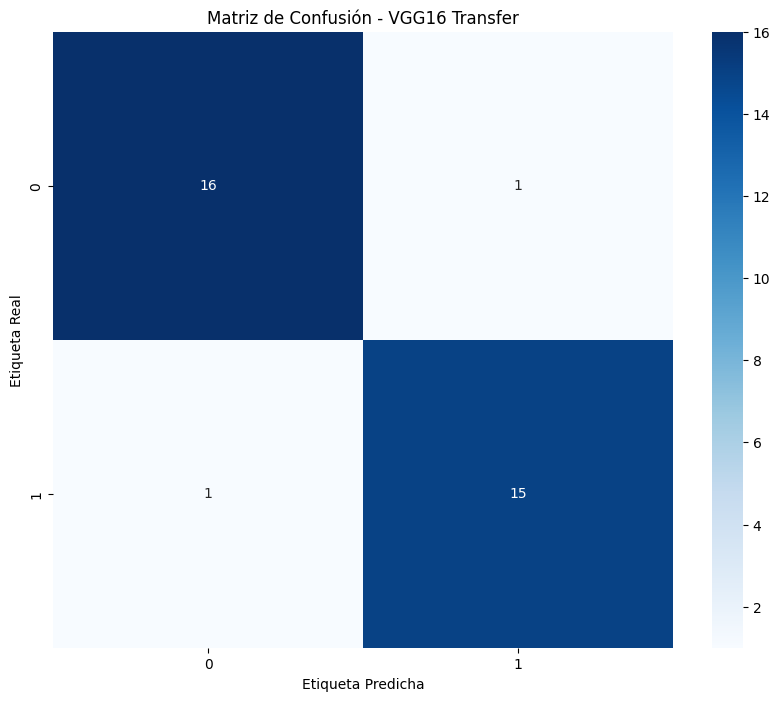

Reporte de Clasificación - Transfer Learning (VGG16)

              precision    recall  f1-score   support

       birds       0.94      0.94      0.94        17
      drones       0.94      0.94      0.94        16

    accuracy                           0.94        33
   macro avg       0.94      0.94      0.94        33
weighted avg       0.94      0.94      0.94        33



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_vgg = history_vgg.history['accuracy']
val_acc_vgg = history_vgg.history['val_accuracy']
loss_vgg = history_vgg.history['loss']
val_loss_vgg = history_vgg.history['val_loss']
epochs_range_vgg = range(len(acc_vgg))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_vgg, acc_vgg, label='Train Accuracy')
plt.plot(epochs_range_vgg, val_acc_vgg, label='Val Accuracy')
plt.legend()
plt.title('Precisión - Transfer Learning (VGG16)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_vgg, loss_vgg, label='Train Loss')
plt.plot(epochs_range_vgg, val_loss_vgg, label='Val Loss')
plt.legend()
plt.title('Pérdida - Transfer Learning (VGG16)')
plt.show()

# Cargar el mejor modelo y evaluar
best_vgg_model = load_model('best_model_vgg.keras')
test_gen.reset()
preds_vgg = best_vgg_model.predict(test_gen, verbose=1)
y_pred_vgg = np.argmax(preds_vgg, axis=1)

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - VGG16 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Transfer Learning (VGG16)")
print()
print(classification_report(y_true, y_pred_vgg, target_names=labels_map, zero_division=0))

## 10. Conclusiones y Discusión

Las siguientes preguntas constituyen el entregable de esta sección. La idea es que las respondan directamente en este mismo notebook, fundamentando sus respuestas con los resultados obtenidos y cualquier análisis relevante.

- **Comparación entre modelo Scratch y el modelo VGG16:**  
  - ¿Cuál obtuvo mejor precisión y cuál converge más rápido?  
  En cuanto a la precisión, el modelo VGG16 supera al modelo convolucional entrenado desde cero, alcanzando una precisión del 94% en el conjunto de prueba, mientras que el modelo convolucional llegó al 67%. En términos de convergencia, visualizando las curvas de entrenamiento, especialmente la de pérdida, se observa que el modelo VGG16 no solo converge más ráído, sino que lo hace de manera más estable, con una disminución constante de la pérdida a lo largo de las épocas. En contraste, el modelo entrenado desde cero muestra una curva de pérdida más errática, tardando más tiempo en alcanzar un rendimiento aceptable.
  - ¿Fue necesario más tiempo para entrenar la red desde cero?  
  Para contestar, es importante calcular el tiempo de entrenamiento de ambos modelos:
    - Modelo Convolucional: 21+4*11+3*2+5=76 segundos
    - Modelo VGG16: 17+4*10+5*4=77 segundos
    Por lo tanto, aunque los tiempo son muy similares, el modelo entrenado desde cero no tomó más tiempo que el modelo VGG16.
  - ¿Por qué la arquitectura pre-entrenada podría ofrecer ventajas cuando el dataset de destino no es enorme?
  Una arquitectura pre-entrenada ofrece ventajas significativas cuando el dataset de destino es limitado porque, gracias al entrenamiento previo en conjuntos masivos como ImageNet, el modelo ya ha aprendido a extraer características visuales generales (como bordes, texturas y formas básicas) que son universales para casi cualquier tarea de clasificación. Al partir de este conocimiento base en lugar de pesos aleatorios, se evita que el modelo intente memorizar el dataset pequeño, lo que reduce drásticamente el riesgo de overfitting y permite una convergencia mucho más rápida. Al entrenar un modelo pequeño desde cero con pocos datos, es común que el modelo se sobreajuste a las particularidades del conjunto de entrenamiento, lo que resulta en un rendimiento deficiente en datos no vistos. En cambio, un modelo pre-entrenado puede generalizar mejor, incluso con un número limitado de muestras, al aprovechar las representaciones ya aprendidas.

- **Experimentación con Otros Modelos Fundacionales:**  
  1. Probar otras arquitecturas, como SqueezeNet, MobileNetV2, ResNet50, InceptionV3 o cualquiera de su elección.  
  2. Ajustar hiperparámetros (tasa de aprendizaje, batch size, número de capas entrenables, etc.).  
  3. Comparar los resultados y analizar por qué ciertos modelos pueden resultar más efectivos en este tipo de problema.

## Experimentación con otros modelos fundacionales


### Inception V3

Se utilizará el modelo fundacional InceptionV3, una arquitectura de red neuronal convolucional diseñada por Google para la clasificación de imágenes y la extracción de características visuales. Su estructura se basa en módulos Inception que ejecutan convoluciones de diferentes tamaños (1x1, 3x3 y 5x5) de forma paralela en una misma capa. Este diseño permite capturar información en múltiples escalas espaciales y obtener representaciones jerárquicas de los datos sin incrementar linealmente el número de parámetros del modelo.

La cabeza de clasificación integrada consta de dos capas densas para el procesamiento de las características extraídas. La primera cuenta con 256 neuronas, función de activación ReLU y un dropout del 30%. La segunda capa dispone de 128 neuronas, activación ReLU y un dropout del 20%. Esta configuración actúa como un clasificador personalizado que adapta los pesos pre-entrenados del modelo base a las etiquetas específicas del dataset de destino, utilizando el dropout como técnica de regularización para reducir el sobreajuste.

In [21]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Cargar InceptionV3 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base para no reentrenarlas
for layer in base_model_inception.layers:
    layer.trainable = False

# Construir el modelo de transfer learning con variaciones en capas y neuronas
model_inception = Sequential([
    base_model_inception,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'), # aumentado a 256 neuronas
    Dropout(0.3), # dropout ajustado a 0.3
    Dense(128, activation='relu'), # capa adicional de 128 neuronas
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Mostrar la arquitectura del modelo
model_inception.summary()

# Compilar el modelo con un Learning Rate personalizado (0.0005)
optimizer = Adam(learning_rate=0.0005)
model_inception.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks para guardar el mejor modelo, detener tempranamente y reducir la tasa de aprendizaje
callbacks_inception = [
    ModelCheckpoint('best_model_inception.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# Entrenar el modelo de transfer learning
epochs_inception = 15
with tf.device('/device:GPU:0'):
    history_inception = model_inception.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_inception,
        callbacks=callbacks_inception
    )

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2, 2, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,360,482 (85.30 MB)

 Trainable params: 557,698 (2.13 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5973 - loss: 1.2859 - val_accuracy: 0.7385 - val_loss: 0.4235 - learning_rate: 5.0000e-04
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 590ms/step - accuracy: 0.7212 - loss: 0.6290 - val_accuracy: 0.9538 - val_loss: 0.1662 - learning_rate: 5.0000e-04
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 636ms/step - accuracy: 0.8496 - loss: 0.3648 - val_accuracy: 0.9385 - val_loss: 0.1645 - learning_rate: 5.0000e-04
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 615ms/step - accuracy: 0.8805 - loss: 0.2616 - val_accuracy: 0.9692 - val_loss: 0.1293 - learning_rate: 5.0000e-04
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step - accuracy: 0.9027 - loss: 0.2506 - val_accuracy: 0.9231 - val_loss: 0.1554 - learning_rate: 5.0000e-04
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 791ms/step - accuracy: 0.8761 - loss: 0.3257 - val_accuracy: 0.9692 - val_loss: 0.1027 - learning_rate: 5.0000e-04
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 551ms/step - accuracy: 0.8761 - loss: 0

A continuación se realiza la evaluación del modelo.

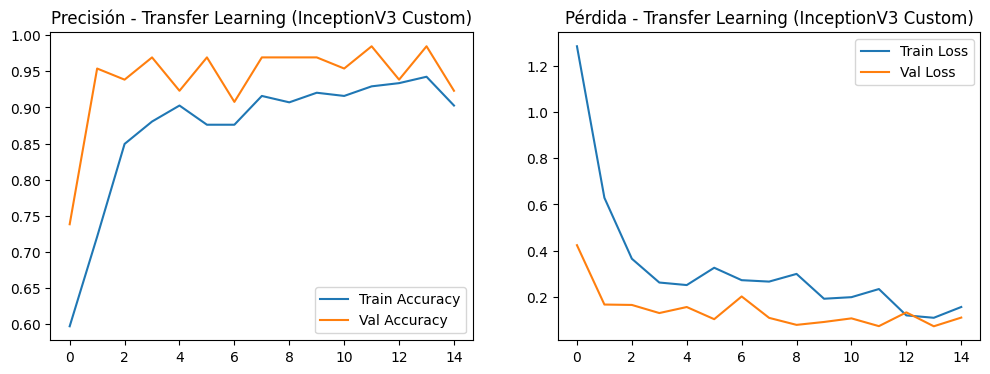

1/2 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step


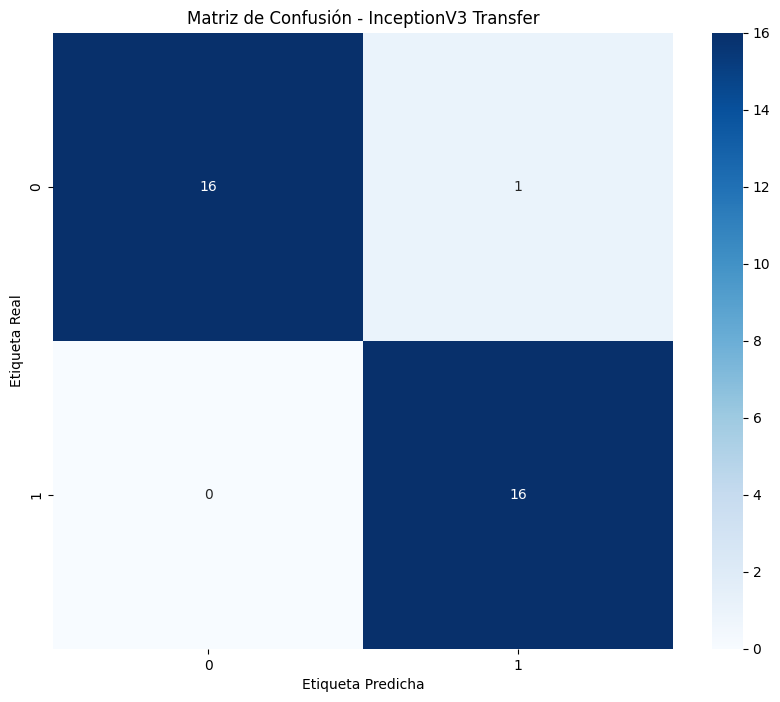

Reporte de Clasificación - Transfer Learning (InceptionV3 Custom)

              precision    recall  f1-score   support

       birds       1.00      0.94      0.97        17
      drones       0.94      1.00      0.97        16

    accuracy                           0.97        33
   macro avg       0.97      0.97      0.97        33
weighted avg       0.97      0.97      0.97        33



In [22]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_inception = history_inception.history['accuracy']
val_acc_inception = history_inception.history['val_accuracy']
loss_inception = history_inception.history['loss']
val_loss_inception = history_inception.history['val_loss']
epochs_range_inception = range(len(acc_inception))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_inception, acc_inception, label='Train Accuracy')
plt.plot(epochs_range_inception, val_acc_inception, label='Val Accuracy')
plt.legend()
plt.title('Precisión - Transfer Learning (InceptionV3 Custom)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_inception, loss_inception, label='Train Loss')
plt.plot(epochs_range_inception, val_loss_inception, label='Val Loss')
plt.legend()
plt.title('Pérdida - Transfer Learning (InceptionV3 Custom)')
plt.show()

# Cargar el mejor modelo y evaluar
best_inception_model = load_model('best_model_inception.keras')
test_gen.reset()
preds_inception = best_inception_model.predict(test_gen, verbose=1)
y_pred_inception = np.argmax(preds_inception, axis=1)

# Extraer etiquetas reales
y_true = test_gen.classes

cm_inception = confusion_matrix(y_true, y_pred_inception)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_inception, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - InceptionV3 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Transfer Learning (InceptionV3 Custom)")
print()
print(classification_report(y_true, y_pred_inception, target_names=labels_map, zero_division=0))

Las curvas de aprendizaje muestran un comportamiento con ciertas oscilaciones; sin embargo, se identifica una tendencia descendente constante en la función de pérdida conforme progresan las épocas. La convergencia de las métricas de entrenamiento y validación indica que el modelo no presenta signos de overfitting, logrando una generalización adecuada hacia datos no vistos.

En cuanto al rendimiento cuantitativo, el modelo alcanzó un accuracy del 97%. El análisis de la matriz de confusión revela que el sistema clasificó correctamente la casi totalidad de las imágenes, registrando únicamente un error de predicción en una muestra perteneciente a la clase "pájaro".

### ResNet50

Para el siguiente experimento, se utilizará el modelo fundacional ResNet50, una arquitectura de red neuronal convolucional de 50 capas de profundidad que utiliza conexiones residuales para facilitar el flujo del gradiente. Este modelo fue diseñado originalmente para procesar imágenes con una resolución nativa de 224x224 píxeles, lo que constituye un estándar optimizado para su estructura interna. Al ser una arquitectura de gran escala, cuenta con un número de parámetros significativamente elevado en comparación con modelos más ligeros, lo que le otorga una alta capacidad de representación, pero también una mayor demanda de recursos.

La cabeza de clasificación personalizada consta de una capa densa de 512 neuronas con activación ReLU y un dropout del 40%. Esta configuración busca gestionar la compleja salida del modelo base y regularizar el aprendizaje, considerando que el gran volumen de parámetros de ResNet50 puede inducir a una memorización de los datos si no se aplica una penalización suficiente. El modelo se compila con una tasa de aprendizaje reducida de 0.0001 para intentar estabilizar la actualización de pesos en una red de estas dimensiones.

In [25]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Cargar ResNet50 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base
for layer in base_model_resnet.layers:
    layer.trainable = False

# Construir el modelo con una capa densa robusta
model_resnet = Sequential([
    base_model_resnet,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'), # capa más ancha para ResNet
    Dropout(0.4), # mayor protección contra overfitting
    Dense(num_classes, activation='softmax')
])

# Mostrar la arquitectura
model_resnet.summary()

# Compilar con Learning Rate más bajo (0.0001)
optimizer = Adam(learning_rate=0.0001)
model_resnet.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks
callbacks_resnet = [
    ModelCheckpoint('best_model_resnet.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# Entrenar
epochs_resnet = 15
with tf.device('/device:GPU:0'):
    history_resnet = model_resnet.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_resnet,
        callbacks=callbacks_resnet
    )

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,637,826 (93.99 MB)

 Trainable params: 1,050,114 (4.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4735 - loss: 0.7486 - val_accuracy: 0.4923 - val_loss: 0.6945 - learning_rate: 1.0000e-04
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 579ms/step - accuracy: 0.4735 - loss: 0.7374 - val_accuracy: 0.4923 - val_loss: 0.6999 - learning_rate: 1.0000e-04
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 793ms/step - accuracy: 0.5044 - loss: 0.7623 - val_accuracy: 0.5692 - val_loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 824ms/step - accuracy: 0.4912 - loss: 0.7292 - val_accuracy: 0.5538 - val_loss: 0.6886 - learning_rate: 1.0000e-04
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 434ms/step - accuracy: 0.4956 - loss: 0.7566 - val_accuracy: 0.5231 - val_loss: 0.6906 - learning_rate: 1.0000e-04
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 508ms/step - accuracy: 0.5354 - loss: 0.7148 - val_accuracy: 0.5385 - val_loss: 0.6878 - learning_rate: 1.0000e-04
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 698ms/step - accuracy: 0.5265 - loss: 

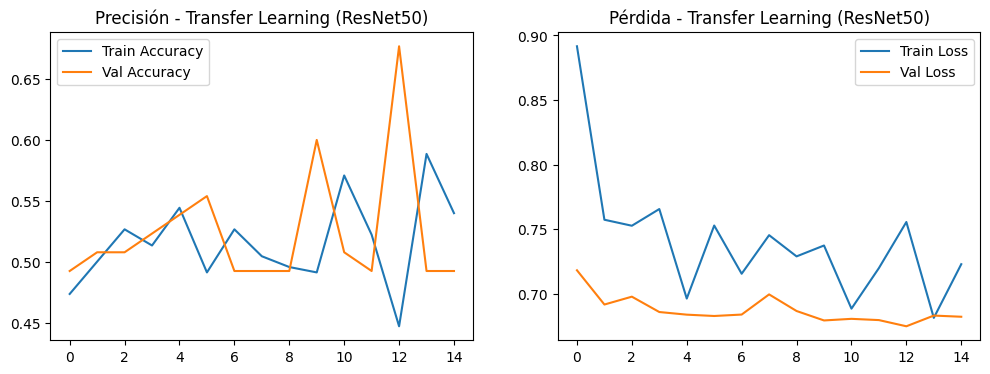

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step


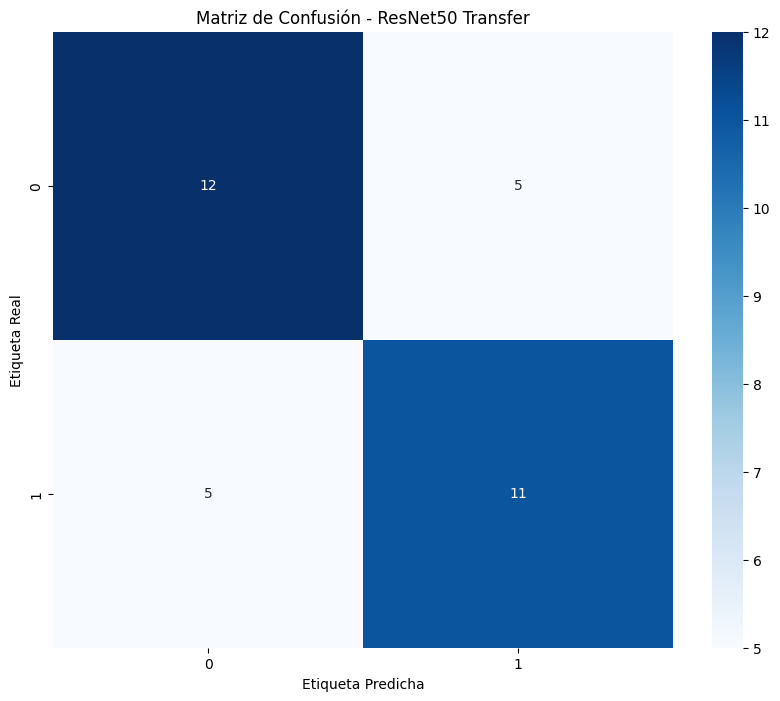

Reporte de Clasificación - Transfer Learning (ResNet50)

              precision    recall  f1-score   support

       birds       0.71      0.71      0.71        17
      drones       0.69      0.69      0.69        16

    accuracy                           0.70        33
   macro avg       0.70      0.70      0.70        33
weighted avg       0.70      0.70      0.70        33



In [24]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_resnet = history_resnet.history['accuracy']
val_acc_resnet = history_resnet.history['val_accuracy']
loss_resnet = history_resnet.history['loss']
val_loss_resnet = history_resnet.history['val_loss']
epochs_range_resnet = range(len(acc_resnet))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_resnet, acc_resnet, label='Train Accuracy')
plt.plot(epochs_range_resnet, val_acc_resnet, label='Val Accuracy')
plt.legend()
plt.title('Precisión - Transfer Learning (ResNet50)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_resnet, loss_resnet, label='Train Loss')
plt.plot(epochs_range_resnet, val_loss_resnet, label='Val Loss')
plt.legend()
plt.title('Pérdida - Transfer Learning (ResNet50)')
plt.show()

# Cargar el mejor modelo y evaluar
best_resnet_model = load_model('best_model_resnet.keras')
test_gen.reset()
preds_resnet = best_resnet_model.predict(test_gen, verbose=1)
y_pred_resnet = np.argmax(preds_resnet, axis=1)

# Extraer etiquetas reales
y_true = test_gen.classes

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - ResNet50 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Transfer Learning (ResNet50)")
print()
print(classification_report(y_true, y_pred_resnet, target_names=labels_map, zero_division=0))

Las curvas de aprendizaje presentan un comportamiento altamente errático, con picos pronunciados y oscilaciones constantes, especialmente en la métrica de precisión. Esta inestabilidad sugiere dificultades del modelo para converger hacia un mínimo global estable. A diferencia de otros modelos, la falta de una tendencia clara y la variabilidad en la validación indican una capacidad de generalización limitada bajo la configuración actual.

En términos de métricas, el modelo alcanzó un accuracy del 70%, un rendimiento notablemente inferior a las arquitecturas probadas anteriormente. El reporte de clasificación muestra un desempeño balanceado pero pobre entre ambas categorías, con una precisión de 0.71 para la clase "pájaro" y 0.69 para la clase "dron". Estos resultados confirman que el modelo presenta dificultades significativas para distinguir las características críticas de cada clase, cometiendo múltiples errores de clasificación en el conjunto de prueba.

### MobileNetV2

Finalmente, se utilizará el modelo fundacional MobileNetV2, una arquitectura diseñada específicamente para dispositivos con recursos computacionales limitados. Su eficiencia radica en el uso de convoluciones separables en profundidad y bloques residuales invertidos, lo que permite reducir drásticamente el número de parámetros y la carga operativa sin sacrificar significativamente la precisión. Al ser una red optimizada para ser ligera, se adapta de manera efectiva a tareas con datasets más pequeños donde modelos más masivos podrían presentar dificultades de convergencia.

La cabeza de clasificación personalizada incluye una capa densa de 128 neuronas con función de activación ReLU, seguida de un dropout del 20% para prevenir el sobreajuste. Esta estructura simplificada busca mantener la ligereza característica de la arquitectura base, permitiendo una buena transferencia de conocimiento desde los pesos pre-entrenados de ImageNet hacia las categorías del dataset objetivo. El modelo se compila con el optimizador Adam.

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

# Cargar MobileNetV2 pre-entrenado en ImageNet, sin incluir la parte superior
base_model_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Congelar todas las capas del modelo base para no reentrenarlas
for layer in base_model_mobilenet.layers:
    layer.trainable = False

# Construir el modelo de transfer learning
model_mobilenet = Sequential([
    base_model_mobilenet,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

# Mostrar la arquitectura del modelo
model_mobilenet.summary()

# Compilar el modelo
model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Definir callbacks para guardar el mejor modelo, detener tempranamente y reducir la tasa de aprendizaje
callbacks_mobilenet = [
    ModelCheckpoint('best_model_mobilenet.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
]

# Entrenar el modelo de transfer learning
epochs_mobilenet = 15
with tf.device('/device:GPU:0'):
    history_mobilenet = model_mobilenet.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_mobilenet,
        callbacks=callbacks_mobilenet
    )

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6195 - loss: 1.0445 - val_accuracy: 0.9538 - val_loss: 0.2081 - learning_rate: 0.0010
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 504ms/step - accuracy: 0.8584 - loss: 0.3106 - val_accuracy: 0.9846 - val_loss: 0.1004 - learning_rate: 0.0010
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 505ms/step - accuracy: 0.9292 - loss: 0.1544 - val_accuracy: 0.9385 - val_loss: 0.1244 - learning_rate: 0.0010
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 465ms/step - accuracy: 0.9602 - loss: 0.1056 - val_accuracy: 0.9846 - val_loss: 0.0522 - learning_rate: 0.0010
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 457ms/step - accuracy: 0.9690 - loss: 0.0821 - val_accuracy: 0.9846 - val_loss: 0.0721 - learning_rate: 0.0010
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 596ms/step - accuracy: 0.9823 - loss: 0.0584 - val_accuracy: 0.9846 - val_loss: 0.0518 - learning_rate: 0.0010
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 489ms/step - accuracy: 0.9602 - loss: 0.0908 - val_accuracy: 0.

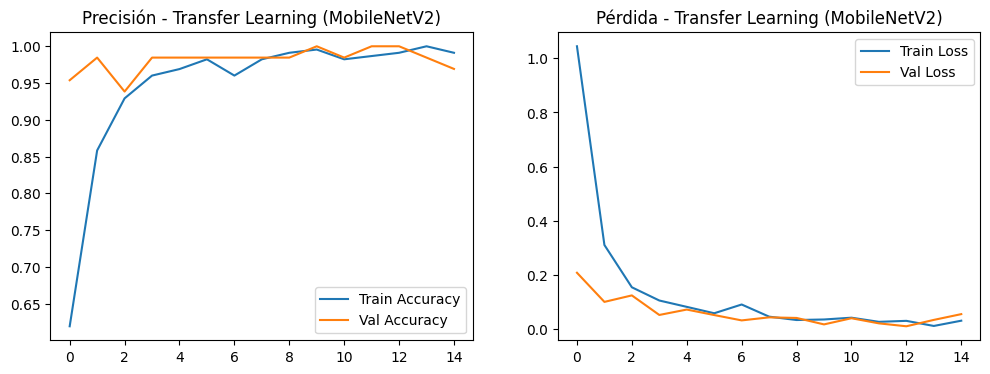

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step


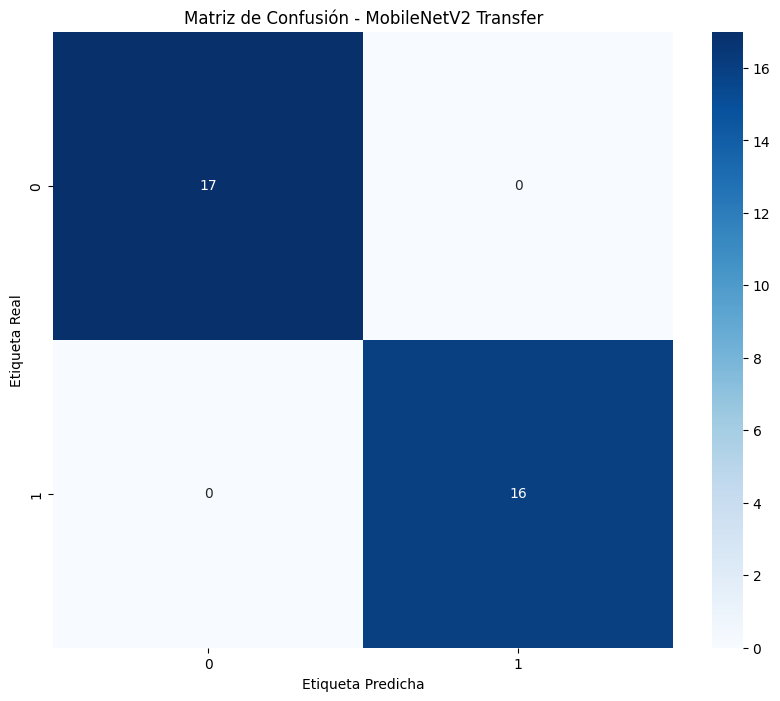

Reporte de Clasificación - Transfer Learning (MobileNetV2)

              precision    recall  f1-score   support

       birds       1.00      1.00      1.00        17
      drones       1.00      1.00      1.00        16

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Graficar la historia de entrenamiento
acc_mobilenet = history_mobilenet.history['accuracy']
val_acc_mobilenet = history_mobilenet.history['val_accuracy']
loss_mobilenet = history_mobilenet.history['loss']
val_loss_mobilenet = history_mobilenet.history['val_loss']
epochs_range_mobilenet = range(len(acc_mobilenet))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_mobilenet, acc_mobilenet, label='Train Accuracy')
plt.plot(epochs_range_mobilenet, val_acc_mobilenet, label='Val Accuracy')
plt.legend()
plt.title('Precisión - Transfer Learning (MobileNetV2)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_mobilenet, loss_mobilenet, label='Train Loss')
plt.plot(epochs_range_mobilenet, val_loss_mobilenet, label='Val Loss')
plt.legend()
plt.title('Pérdida - Transfer Learning (MobileNetV2)')
plt.show()

# Cargar el mejor modelo y evaluar
best_mobilenet_model = load_model('best_model_mobilenet.keras')
test_gen.reset()
preds_mobilenet = best_mobilenet_model.predict(test_gen, verbose=1)
y_pred_mobilenet = np.argmax(preds_mobilenet, axis=1)

cm_mobilenet = confusion_matrix(test_gen.classes, y_pred_mobilenet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - MobileNetV2 Transfer')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

print("Reporte de Clasificación - Transfer Learning (MobileNetV2)")
print()
print(classification_report(test_gen.classes, y_pred_mobilenet, target_names=labels_map, zero_division=0))

Las curvas de aprendizaje reflejan un comportamiento óptimo, caracterizado por una progresión suave y una convergencia clara hacia valores de pérdida mínimos. La estabilidad en la evolución de las métricas de entrenamiento y validación confirma la ausencia de sobreajuste, demostrando que el modelo ha logrado extraer características genéricas y robustas que le permiten una generalización perfecta sobre el conjunto de datos.

En cuanto al rendimiento cuantitativo, el modelo alcanzó una precisión del 100%. Estos resultados indican que la arquitectura MobileNetV2, bajo la configuración implementada, es capaz de discriminar con total exactitud pájaros de drones.

## Discusión de resultados

Al comparar los resultados obtenidos con los tres modelos fundacionales utilizados, se hace evidente que el éxito en la tarea de clasificación dependió de la complejidad de la arquitectura y el tamaño reducido del dataset. Con un conjunto de entrenamiento limitado a 166 muestras, la capacidad de generalización estuvo condicionada no solo por la naturaleza de las redes, sino por el diseño específico de las cabezas de clasificación y la precisión en el ajuste del learning rate.

En este escenario, MobileNetV2 destacó como la opción más eficiente al alcanzar una precisión del 100%. Este resultado se logró mediante una configuración equilibrada que utilizó una cabeza de clasificación de 128 neuronas y una tasa de aprendizaje estándar con el optimizador Adam. Al ser una arquitectura optimizada para la ligereza, su menor volumen de parámetros facilitó la convergencia, permitiendo que el modelo extrajera características esenciales sin caer en el ruido o el sobreajuste que suelen presentar redes más pesadas ante pocos datos.

Por otro lado, InceptionV3 mantuvo un rendimiento muy competitivo, del 97%, apoyándose en una estructura de clasificación más profunda con dos capas densas de 256 y 128 neuronas. Esta jerarquía permitió procesar la información multiescala característica de los módulos Inception, mientras que la reducción del learning rate a 0.0005 fue fundamental para estabilizar el entrenamiento. Gracias a este ajuste fino, el modelo pudo capturar diferencias morfológicas entre pájaros y drones, logrando una transición exitosa desde el conocimiento pre-entrenado hacia las particularidades del dataset con el que se está trabajando.

Finalmente, el desempeño de ResNet50 resultó deficiente, con un accuracy de apenas el 70% y un comportamiento altamente errático en el aprendizaje. A pesar de haber implementado una capa densa robusta de 512 neuronas y una tasa de aprendizaje baja, de 0.0001, para forzar la estabilidad, el elevado número de parámetros del modelo fundacional no funcionó correctamente para este conjunto de datos. La rigidez de esta arquitectura masiva ante un volumen de datos tan pequeño impidió una adaptación fluida, confirmando que, en entornos de recursos limitados, el exceso de complejidad puede convertirse en un obstáculo para el aprendizaje en lugar de una ventaja.